In [4]:
import pandas as pd
import numpy as np

from scipy.stats import pearsonr, spearmanr

import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("penguins")

df.head()

df.info()
df.describe()
df.isna().sum()

df = df.dropna()

numeric_cols = df.select_dtypes(include=np.number).columns
numeric_cols

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 24.9 KB


Index(['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'], dtype='str')

The dataset contains measurements of penguins including bill length, bill depth, flipper length, and body mass.

The dataset also includes categorical variables such as species, sex, and island, which allow subgroup analysis.

Missing values were removed using dropna() to ensure accurate correlation calculations.

In [7]:
pearson_corr = df[numeric_cols].corr(method="pearson")
pearson_corr

spearman_corr = df[numeric_cols].corr(method="spearman")
spearman_corr

results = []

for col1 in numeric_cols:
    for col2 in numeric_cols:
        if col1 != col2:

            pearson_r, pearson_p = pearsonr(df[col1], df[col2])
            spearman_r, spearman_p = spearmanr(df[col1], df[col2])

            results.append({
                "Feature 1": col1,
                "Feature 2": col2,
                "Pearson r": pearson_r,
                "Pearson p": pearson_p,
                "Spearman rho": spearman_r,
                "Spearman p": spearman_p
            })

summary_table = pd.DataFrame(results)

summary_table.drop_duplicates(subset=["Pearson r"])

,Feature 1,Feature 2,Pearson r,Pearson p,Spearman rho,Spearman p
0,bill_length_mm,bill_depth_mm,-0.228626,2.528290e-05,-0.213859,8.371954e-05
1,bill_length_mm,flipper_length_mm,0.653096,7.211341e-42,0.669754,1.073660e-44
2,bill_length_mm,body_mass_g,0.589451,1.538614e-32,0.576480,6.972018e-31
4,bill_depth_mm,flipper_length_mm,-0.577792,4.778177e-31,-0.517317,3.456493e-24
5,bill_depth_mm,body_mass_g,-0.472016,7.024160e-20,-0.429283,2.307299e-16
8,flipper_length_mm,body_mass_g,0.872979,3.132836e-105,0.840390,4.630424e-90


The strongest linear relationship is observed between flipper_length_mm and body_mass_g, with a high positive Pearson correlation.

This indicates that penguins with longer flippers tend to have greater body mass.

Pearson and Spearman correlations are generally similar across most feature pairs, suggesting that relationships are largely monotonic and approximately linear.

Small differences between the two measures may occur due to non-linear trends or mild outliers.

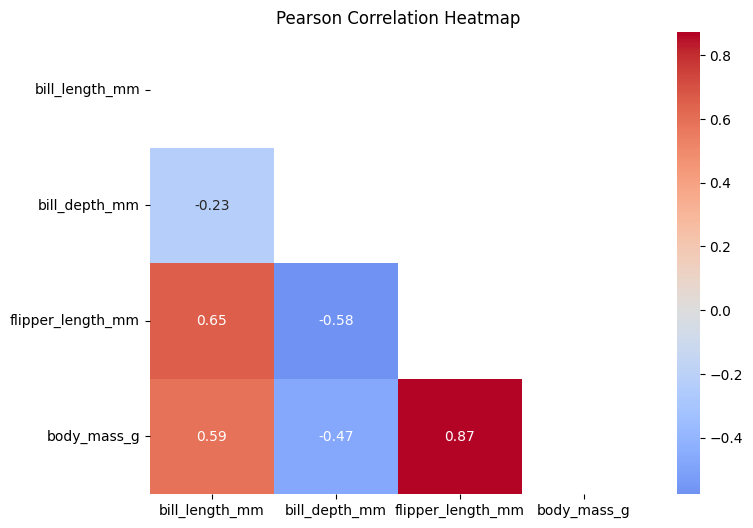

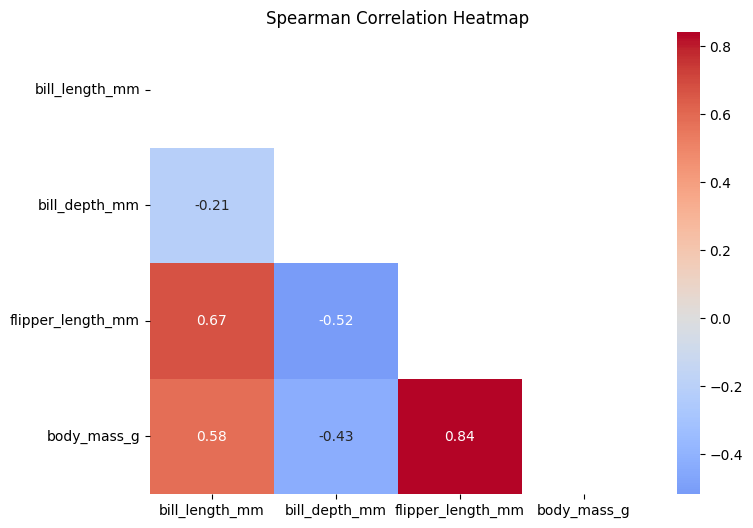

In [8]:
mask = np.triu(np.ones_like(pearson_corr, dtype=bool))

plt.figure(figsize=(8,6))

sns.heatmap(
    pearson_corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    mask=mask,
    fmt=".2f"
)

plt.title("Pearson Correlation Heatmap")
plt.show()

mask = np.triu(np.ones_like(spearman_corr, dtype=bool))

plt.figure(figsize=(8,6))

sns.heatmap(
    spearman_corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    mask=mask,
    fmt=".2f"
)

plt.title("Spearman Correlation Heatmap")
plt.show()



The Pearson and Spearman heatmaps show largely consistent patterns across the dataset.

Both methods identify flipper length and body mass as strongly positively correlated.

Differences between Pearson and Spearman correlations are relatively small, indicating that most relationships are monotonic and close to linear.

If Spearman values were significantly higher than Pearson values, it would suggest a monotonic but non-linear relationship.

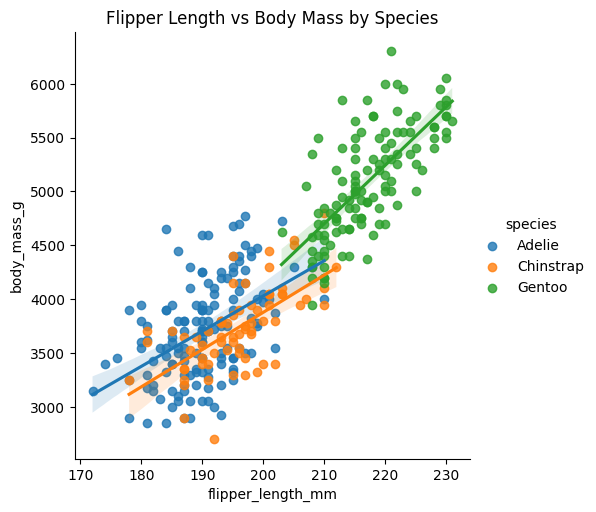

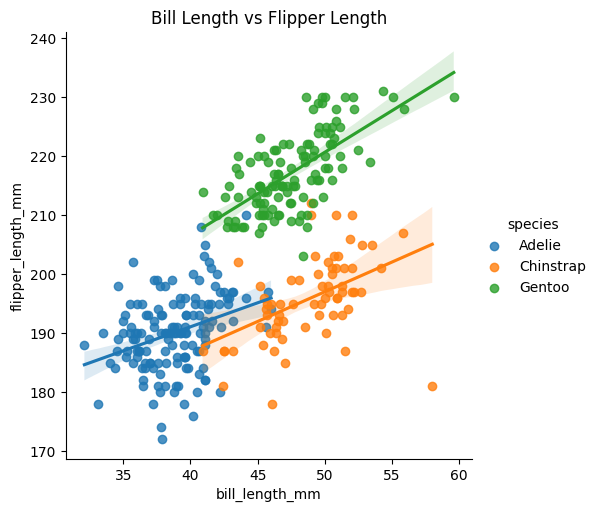

In [11]:
corr_pairs = pearson_corr.abs().unstack().sort_values(ascending=False)
corr_pairs

sns.lmplot(
    data=df,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species"
)

plt.title("Flipper Length vs Body Mass by Species")
plt.show()

sns.lmplot(
    data=df,
    x="bill_length_mm",
    y="flipper_length_mm",
    hue="species"
)

plt.title("Bill Length vs Flipper Length")
plt.show()



The scatterplots reveal that the overall regression line captures the general trend in the data.

However, when colored by species, the penguins form distinct clusters. Each species shows slightly different slopes and intercepts, indicating that species influences the relationship between physical measurements.

This demonstrates how subgroup structure can influence correlations, and highlights the importance of examining relationships visually rather than relying solely on correlation coefficients.

When examining the scatterplots by species, the relationships between variables can differ from the aggregate correlation. This phenomenon is related to Simpson's paradox, where trends that appear in aggregated data may disappear or reverse when data is separated into subgroups.